# Predicting the sale price of bulldozers using Machine Learning
 In this notebook, we are going to build a machine learning model with the aim of predicting the sale price of bulldozers

## 1. Problem Definition
> How  well can we predict the future prices of bulldozers given examples of previous sale prices of bulldozers of similar types or of the same characteristics?

## 2. Data
 The dataset was obtained from the "Blue Book for Bulldozers" Kaggle competition: https://www.kaggle.com/c/bluebook-for-bulldozers/data.
 
 The data for this competition is split into three parts:
 - Train.csv is the training set, which contains data through the end of 2011.
 - Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012 You make predictions on this set throughout the majority
   of the competition. Your score on this set is used to create the public leaderboard.
 - Test.csv is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your
   score on the test set determines your final rank for the competition.
 
## 3. Evaluation 
 The evaluation metric for this project is the RMSLE (root mean squared log error) between the actual and predicted auction prices. Futher details can be found here: www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation
 
 **Note** The goal for most regression models is to minimize the error. For example, the aim of this project is to build a machine learning model that minimizes the RMSLE

## 4. Features
 The features of this dataset can be found in this google sheet: https://docs.google.com/spreadsheets/d/1X-RZ8_KcttNAIBBwqfKuvId7h7xjGcVM-kKGGlkFEFI/edit?usp=sharing

In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sklearn 

In [2]:
#Importing dataset
df = pd.read_csv("data/TrainAndValid.csv" , low_memory = False)
df

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,6333344,10000.0,1919201,21435,149,2.0,2005,NaN,NaN,3/7/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412694,6333345,10500.0,1882122,21436,149,2.0,2005,NaN,NaN,1/28/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412695,6333347,12500.0,1944213,21435,149,2.0,2005,NaN,NaN,1/28/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412696,6333348,10000.0,1794518,21435,149,2.0,2006,NaN,NaN,3/7/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN


In [3]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [5]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

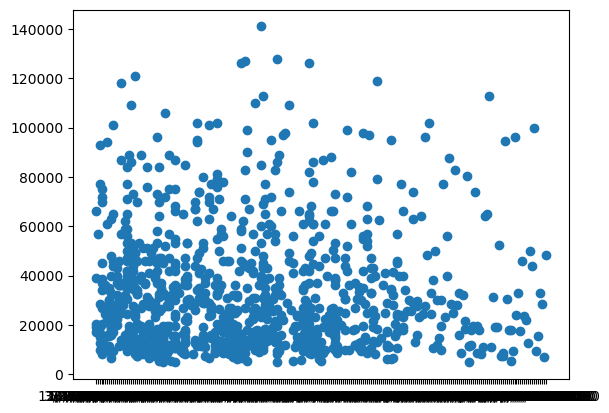

In [6]:
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000]);

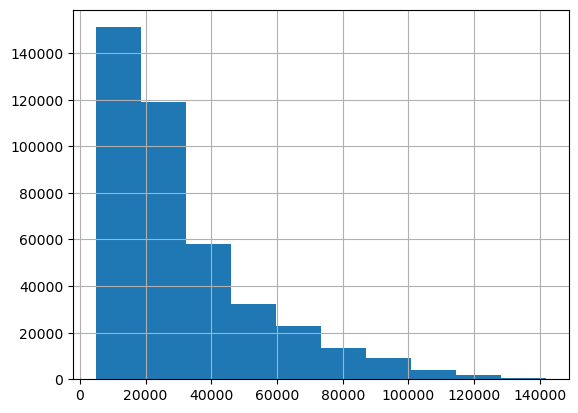

In [7]:
df.SalePrice.hist();

### Parsing Dates
 When working with time series, it is better to enrich the date and time data as much as possible. This can be achieved by using the `parse_date` parameter.

In [8]:
df.saledate.dtype

dtype('O')

In [9]:
# Import csv again but parse dates
df = pd.read_csv("data/TrainAndValid.csv",
                 low_memory = False 
                 ,parse_dates= ["saledate"])

In [10]:
df.saledate.head()

0   2006-11-16
1   2004-03-26
2   2004-02-26
3   2011-05-19
4   2009-07-23
Name: saledate, dtype: datetime64[ns]

In [11]:
df.saledate.dtype

dtype('<M8[ns]')

### Sort data according to date

In [12]:
# Sort data according to saledate
df.sort_values(by= ["saledate"],
              inplace = True,
              ascending = True)

In [13]:
df.saledate.head(10)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
Name: saledate, dtype: datetime64[ns]

In [14]:
df.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


### Make a copy of the data

In [15]:
df_temp = df.copy()

### Add datetime parameters for `saledate` column

In [16]:
df_temp["saleYear"] = df.saledate.dt.year
df_temp["saleMonth"] = df.saledate.dt.month
df_temp["saleDay"] = df.saledate.dt.day
df_temp["saleDayOfTheWeek"] = df.saledate.dt.day_of_week
df_temp["saleDayOfTheYear"] = df.saledate.dt.day_of_year

In [17]:
df_temp.drop("saledate", axis= 1, inplace= True)

In [18]:
df_temp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,A66,D7G,A62,D3B


## Data Preprocessing
 Before modelling can begin, some data preprocessing has to be done. It consists of two parts:  
 
 - Converting categorical data to numerical data
 - Filling in missing data(numerical and categorical)

### Converting data to numbers

In [19]:
# This shows the "string" datatypes
for label, content in df_temp.items():
    if pd.api.types.is_string_dtype(content) or pd.api.types.is_object_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [20]:
# This coverts all string datatypes to categorical datatypes
for label, content in df_temp.items():
    if pd.api.types.is_string_dtype(content) or pd.api.types.is_object_dtype(content):
        df_temp[label] = content.astype("category").cat.as_ordered()

In [21]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [22]:
# Check percentage of missing data
(df_temp.isna().sum()/len(df_temp)) * 100

SalesID                      0.000000
SalePrice                    0.000000
MachineID                    0.000000
ModelID                      0.000000
datasource                   0.000000
auctioneerID                 4.879113
YearMade                     0.000000
MachineHoursCurrentMeter    64.258610
UsageBand                   82.149174
fiModelDesc                  0.000000
fiBaseModel                  0.000000
fiSecondaryDesc             34.099269
fiModelSeries               85.784520
fiModelDescriptor           81.871490
ProductSize                 52.485110
fiProductClassDesc           0.000000
state                        0.000000
ProductGroup                 0.000000
ProductGroupDesc             0.000000
Drive_System                74.051970
Enclosure                    0.080931
Forks                       52.092087
Pad_Type                    80.349796
Ride_Control                62.992794
Stick                       80.349796
Transmission                54.444412
Turbocharged

In [23]:
# Saving test dataset
df_temp.to_csv("data/train_temp.csv",
              index = False)

### Filling in missing numeric data

In [24]:
#Find numeric data
for label, content in df_temp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayOfTheWeek
saleDayOfTheYear


In [25]:
# Find missing numeric data
for label, content in df_temp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

auctioneerID
MachineHoursCurrentMeter


In [26]:
# Fill the missing values
for label, content in df_temp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add a binary column to tell if data was missing
            df_temp[label + "is missing"] = pd.isnull(content)
            # Fill the missing values with the mediam
            df_temp[label] = content.fillna(content.median())

In [27]:
# Check again for missing values
for label, content in df_temp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

### Filling missing categorical data

In [28]:
df_temp.isna().sum()

SalesID                                    0
SalePrice                                  0
MachineID                                  0
ModelID                                    0
datasource                                 0
auctioneerID                               0
YearMade                                   0
MachineHoursCurrentMeter                   0
UsageBand                             339028
fiModelDesc                                0
fiBaseModel                                0
fiSecondaryDesc                       140727
fiModelSeries                         354031
fiModelDescriptor                     337882
ProductSize                           216605
fiProductClassDesc                         0
state                                      0
ProductGroup                               0
ProductGroupDesc                           0
Drive_System                          305611
Enclosure                                334
Forks                                 214983
Pad_Type  

In [29]:
# Check for remaining missing data
for label, content in df_temp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [30]:
# Converting categories to numerical datatype
for label, content in df_temp.items():
    if not pd.api.types.is_numeric_dtype(content):
         # Add a binary column to tell if data was missing
        df_temp[label + "is missing"] = pd.isna(content)
        # Add categories into numbers and add + 1
        df_temp[label] = pd.Categorical(content).codes + 1

In [31]:
df_temp.isna().sum()

SalesID                        0
SalePrice                      0
MachineID                      0
ModelID                        0
datasource                     0
                              ..
Backhoe_Mountingis missing     0
Blade_Typeis missing           0
Travel_Controlsis missing      0
Differential_Typeis missing    0
Steering_Controlsis missing    0
Length: 103, dtype: int64

# Modelling

### Random Forest Regressor

In [32]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

In [33]:
%%time

model = RandomForestRegressor(n_jobs = -1 ,
                             random_state= 42)

model.fit(df_temp.drop("SalePrice", axis = 1), df_temp["SalePrice"])

CPU times: total: 30min 25s
Wall time: 9min


RandomForestRegressor(n_jobs=-1, random_state=42)

In [34]:
# Splitting data into training and validation datasets
df_val = df_temp[df_temp.saleYear == 2012]
df_train = df_temp[df_temp.saleYear != 2012]

In [35]:
X_train , y_train = df_train.drop("SalePrice", axis = 1), df_train["SalePrice"]
X_valid , y_valid = df_val.drop("SalePrice", axis = 1), df_val["SalePrice"]

In [36]:
# Reducing data using max_samples
model = RandomForestRegressor(n_jobs = -1,
                             random_state = 42,
                             max_samples = 10000)

In [37]:
%%time

model.fit(X_train, y_train)

CPU times: total: 1min 4s
Wall time: 22.2 s


RandomForestRegressor(max_samples=10000, n_jobs=-1, random_state=42)

### XGBoost

In [67]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state =42)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [56]:
# Create evaluation function for scoring model(the competition requires RMSLE)
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle (y_true, y_preds):
    y_preds = np.array(y_preds)
    y_true = np.array(y_true)
    return np.sqrt(mean_squared_log_error(y_true,y_preds))

def model_scoring (model):
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    scores = {"Train MAE": mean_absolute_error(y_train, train_preds), 
             "Valid MAE": mean_absolute_error(y_valid, valid_preds),
              "Train RMSLE": rmsle(y_train, train_preds),
              "Valid RMSLE": rmsle(y_valid, valid_preds),
              "Train R2 score": r2_score(y_train, train_preds),
              "Valid R2 score": r2_score(y_valid, valid_preds)
             }    
    return scores

### Randomized Search CV

In [43]:
%%time

from sklearn.model_selection import RandomizedSearchCV

# Create a search grid for RandomizedSearchCV
rf_grid = {"n_estimators": np.arange(10,100,10),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2,20,2),
           "min_samples_leaf": np.arange(1,20,2),
           "max_features": [0.5,1 ,"sqrt","log2"],
           "max_samples": [10000]}

# RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs = -1,
                                                   random_state= 42),
                              param_distributions = rf_grid,
                              n_iter = 100,
                              cv =5,
                              verbose = True
                             )

# Fit the model
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 30min 13s
Wall time: 14min 33s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=100,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt',
                                                         'log2'],
                                        'max_samples': [10000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
                   verbose=True)

In [70]:
%%time

# For XGBoost
from sklearn.model_selection import RandomizedSearchCV

# Create a search grid for RandomizedSearchCV
xg_grid = {"n_estimators": np.arange(10,100,10),
           "max_depth": [None, 3, 5, 7, 10],
           "learning_rate": np.arange(0.1,1,0.1),
           "subsample": np.arange(0.1,1,0.1),
           "reg_alpha": np.arange(0.1,1,0.1),
           "reg_lambda": np.arange(0.1,1,0.1),}

# RandomizedSearchCV model
xg_model = RandomizedSearchCV(XGBRegressor(n_jobs = -1,
                                                   random_state= 42),
                              param_distributions = xg_grid,
                              n_iter = 100,
                              cv =5,
                              verbose = True
                             )

# Fit the model
xg_model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: total: 2h 58min 31s
Wall time: 1h 4min 32s


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                   n_iter=100,
                   param_distributions={'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                                        'max_depth': [None, 3, 5, 7, 10],
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90]),
                                        'reg_alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                                        'reg_lambda': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                                        'subsample': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
                   verbose=True)

### Training a model with the best hyperparameters

In [81]:
# Ideal XGBooster Model
ideal_rf_model =RandomForestRegressor(max_features=0.5, max_samples= None, min_samples_leaf=3,
                      n_estimators=50, n_jobs=-1, random_state=42)

ideal_rf_model.fit(X_train, y_train)

RandomForestRegressor(max_features=0.5, min_samples_leaf=3, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [83]:
model_scoring(ideal_rf_model)

{'Train MAE': 2529.859147487359,
 'Valid MAE': 5930.432809426988,
 'Train RMSLE': np.float64(0.12895309819133627),
 'Valid RMSLE': np.float64(0.24386885517724988),
 'Train R2 score': 0.9674261418146756,
 'Valid R2 score': 0.8814145653607653}

In [79]:
%time

# Ideal XGBooster Model
ideal_xg_model = XGBRegressor(subsample= np.float64(0.8), 
                              reg_lambda= np.float64(0.6), 
                              reg_alpha= np.float64(0.9), 
                              n_estimators= np.int64(70), 
                              max_depth= 10, 
                              learning_rate= np.float64(0.1))
ideal_xg_model.fit(X_train,y_train)

CPU times: total: 0 ns
Wall time: 0 ns


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=np.float64(0.1),
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=np.int64(70), n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [80]:
model_scoring(ideal_xg_model)

{'Train MAE': 4321.651984379869,
 'Valid MAE': 6183.678393303649,
 'Train RMSLE': np.float64(0.21108386850203986),
 'Valid RMSLE': np.float64(0.2582157371953732),
 'Train R2 score': 0.9190911700710442,
 'Valid R2 score': 0.8745443560154593}

## Making predictions using our model
 Predictions will be made on the test data set using the best or most optimal model we have fitted (Random Forest: 0.2438)

In [85]:
# Import test data set
test_df =pd.read_csv("data/Test.csv",
                     low_memory= False,
                     parse_dates= ["saledate"])
test_df.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


In [86]:
# Preprocessing the test dataser so that predictions can be made
def data_preprocessor (df):
    df["saleYear"] = df.saledate.dt.year
    df["saleMonth"] = df.saledate.dt.month
    df["saleDay"] = df.saledate.dt.day
    df["saleDayOfTheWeek"] = df.saledate.dt.day_of_week
    df["saleDayOfTheYear"] = df.saledate.dt.day_of_year

    df.drop("saledate", 
            axis = 1,
           inplace = True)

    # This coverts all string datatypes to categorical datatypes
    for label, content in df.items():
        if pd.api.types.is_string_dtype(content) or pd.api.types.is_object_dtype(content):
            df_temp[label] = content.astype("category").cat.as_ordered()

    # Fill the missing values
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # Add a binary column to tell if data was missing
                df[label + "is missing"] = pd.isnull(content)
                # Fill the missing values with the mediam
                df[label] = content.fillna(content.median())

    for label, content in df.items():
        if not pd.api.types.is_numeric_dtype(content):
            # Add a binary column to tell if data was missing
            df[label + "is missing"] = pd.isna(content)
            # Add categories into numbers and add + 1
            df[label] = pd.Categorical(content).codes + 1
        
    return df

In [87]:
test_df_processed = data_preprocessor(test_df)
test_df_processed

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Widthis missing,Stick_Lengthis missing,Thumbis missing,Pattern_Changeris missing,Grouser_Typeis missing,Backhoe_Mountingis missing,Blade_Typeis missing,Travel_Controlsis missing,Differential_Typeis missing,Steering_Controlsis missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12452,6643171,2558317,21450,149,2,2008,3525.0,0,713,235,...,False,False,False,False,False,True,True,True,True,True
12453,6643173,2558332,21434,149,2,2005,3525.0,0,186,80,...,False,False,False,False,False,True,True,True,True,True
12454,6643184,2558342,21437,149,2,1000,3525.0,0,325,123,...,False,False,False,False,False,True,True,True,True,True
12455,6643186,2558343,21437,149,2,2006,3525.0,0,325,123,...,False,False,False,False,False,True,True,True,True,True


In [88]:
# The model still doesn't work due to difference in columns 
set (X_train.columns) - set (test_df_processed.columns)

#auctioneerIDis missing is the column that is different

{'auctioneerIDis missing'}

In [89]:
test_df_processed["auctioneerIDis missing"] = False
test_df_processed

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Stick_Lengthis missing,Thumbis missing,Pattern_Changeris missing,Grouser_Typeis missing,Backhoe_Mountingis missing,Blade_Typeis missing,Travel_Controlsis missing,Differential_Typeis missing,Steering_Controlsis missing,auctioneerIDis missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,False
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,False,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,True,True,True,True,True,False
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,True,True,True,True,True,False
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12452,6643171,2558317,21450,149,2,2008,3525.0,0,713,235,...,False,False,False,False,True,True,True,True,True,False
12453,6643173,2558332,21434,149,2,2005,3525.0,0,186,80,...,False,False,False,False,True,True,True,True,True,False
12454,6643184,2558342,21437,149,2,1000,3525.0,0,325,123,...,False,False,False,False,True,True,True,True,True,False
12455,6643186,2558343,21437,149,2,2006,3525.0,0,325,123,...,False,False,False,False,True,True,True,True,True,False


In [90]:
# Reordering the dataset to be identical to data fitted with the model
feature_order = ideal_rf_model.feature_names_in_

In [91]:
data_reordered = test_df_processed[feature_order]

In [92]:
# Now that the columns are in the same format, predictions can be made
test_preds = ideal_rf_model.predict(data_reordered)

In [54]:
test_preds

array([16958.36111111, 16912.69761905, 51551.31349206, ...,
       11894.65638528, 16915.37481962, 30410.61366411], shape=(12457,))

The data is to be put into a particular format as was given during the competitiion: https://www.kaggle.com/competitions/bluebook-for-bulldozers/rules

In [93]:
df_preds = pd.DataFrame()
df_preds["SalesID"] = data_reordered["SalesID"]
df_preds["SalesPrice"] = test_preds
df_preds.head()

,SalesID,SalesPrice
0,1227829,16958.361111
1,1227844,16912.697619
2,1227847,51551.313492
3,1227848,65308.186508
4,1227863,52413.608730


In [94]:
df_preds.to_csv("data/test_predictions.csv", index = False)

## Feature Importance
 This deals with the highlighting of the features that contribute the most to the prediction of the target variable(SalesPrice)

In [97]:
# The feature importance
importance= ideal_rf_model.feature_importances_

In [98]:
# Creating a function to plot the feature importances
def plot_importance (columns, importance, n = 20):
    df = (pd.DataFrame({"Features": columns,
                      "Feature Importances": importance})
          .sort_values("Feature Importances", ascending = False)
          .reset_index(drop=True)
         )

    fig,ax = plt.subplots()
    ax.barh(df["Features"][:n], df["Feature Importances"][:n])
    ax.set_ylabel("Features")
    ax.set_xlabel( "Feature Importance")
    ax.invert_yaxis()

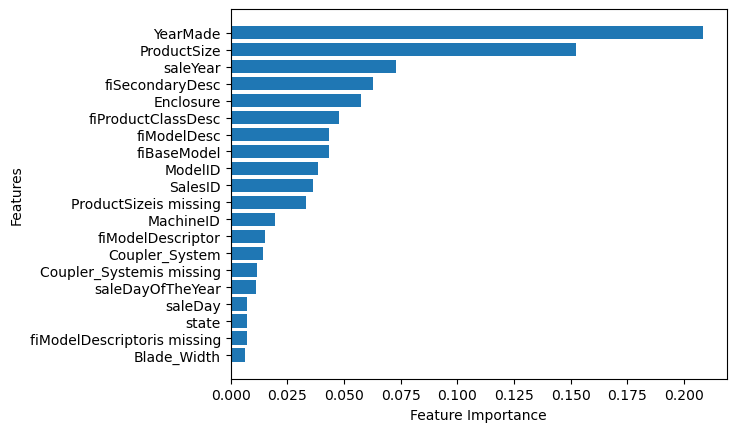

In [99]:
plot_importance(data_reordered.columns, importance)